# 第43篇｜回归诊断：多重共线性 / 异方差 / 自相关

> 这是「数据分析从入门到精通」系列的第 43 篇。会评估模型了，这篇来聊更进一步的问题——回归诊断。多重共线性、异方差、自相关，这三个"隐藏 bug"如果不处理，模型结果会有严重偏差，这篇教你怎么发现和解决它们。

---

嗨，我是小荷～

上一篇学了怎么评估回归模型，今天来学诊断——当模型"不对劲"的时候，怎么找出问题所在。

三大问题：多重共线性、异方差、自相关，都会让你的回归系数和 p 值变得不可信。

---

## 一、多重共线性（Multicollinearity）

回归模型里，两个或多个自变量 X 之间高度相关，长得太像，分不清谁在影响 Y。比如：身高 vs 体重，，温度 vs 空调耗电量，年龄 vs 出生年份 → 完全共线性。它会造成如系数符号反过来（明明正相关，算出负的），系数忽大忽小，不稳定，整体 R² 很高，但单个变量不显著（p 值很大），标准误变大等问题，导致结论不可靠。

**问题描述**：自变量之间高度相关，导致系数估计不稳定、p 值虚假。

**症状**：R² 很高，但每个变量的系数都不显著；系数方向和预期相反。

**诊断工具：VIF（variance_inflation_factor，方差膨胀因子）**


In [1]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
n = 200

# 构造有共线性的数据
x1 = np.random.uniform(0, 10, n)
x2 = x1 * 0.9 + np.random.normal(0, 1, n)   # x2 高度依赖 x1
x3 = np.random.uniform(0, 10, n)
y  = 3*x1 + 2*x3 + np.random.normal(0, 5, n)

df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3, 'y': y})

X = df[['x1', 'x2', 'x3']]
X_sm = sm.add_constant(X)

# 计算 VIF
vif = pd.DataFrame({
    '特征': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("VIF（方差膨胀因子）：")
print(vif)
print("\nVIF 解读：")
print("  < 5 ：无共线性问题")
print("  5~10：轻度共线性，需注意")
print("  > 10：严重共线性，必须处理")


VIF（方差膨胀因子）：
   特征        VIF
0  x1  29.592503
1  x2  29.384969
2  x3   1.959084

VIF 解读：
  < 5 ：无共线性问题
  5~10：轻度共线性，需注意
  > 10：严重共线性，必须处理


**处理方法**：
1. 删除一个高度相关的变量
2. 主成分分析（PCA）降维
3. 使用 Ridge/Lasso 正则化（下下篇会讲）

---

## 二、异方差（Heteroscedasticity）

在线性回归中，误差项的方差不是常数，而是随着 x 变化而变化。同方差（理想）：所有数据点的波动大小一样；异方差（问题）：有的点波动小，有的点波动很大，最常见的是：**x 越大，误差波动越大 → 呈扇形散开**。

它会造成回归系数仍然是无偏的（估计值差不多对），但标准误错了 → p 值不可靠；假设检验失效（你以为显著，其实不显著）等问题，导致模型预测精度下降。

**问题描述**：残差的方差随着拟合值变化，违反了"方差齐性"假设。

**症状**：残差 vs 拟合值图呈扇形扩散。

下面我们用代码来走一遍`模拟异方差数据 → 线性回归 → 画图观察异方差 → 用统计检验（BP 检验）验证异方差存在`的过程


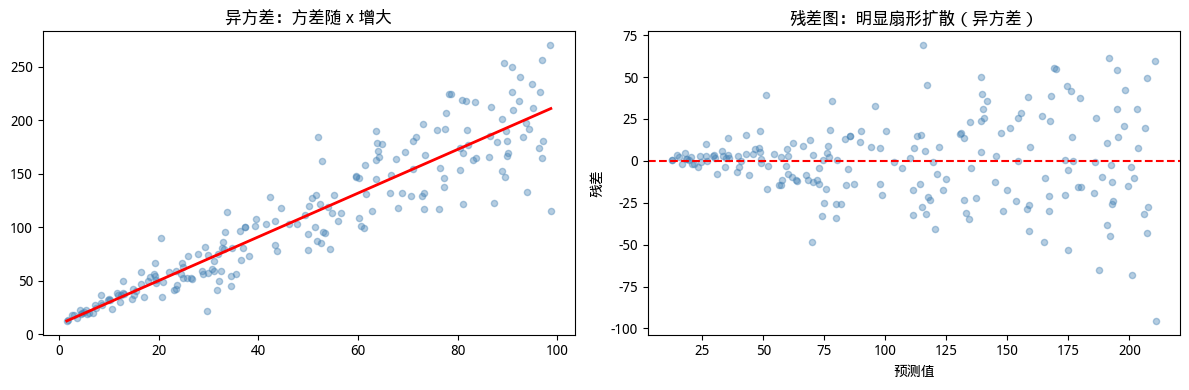


Breusch-Pagan 异方差检验：
  LM统计量: 40.2728
  LM p值: 0.0000
  F统计量: 49.9228
  F p值: 0.0000
结论： 存在异方差（p < 0.05）


In [4]:
np.random.seed(42)
n = 200
x_het = np.random.uniform(1, 100, n)
# 方差随 x 增大：异方差
y_het = 10 + 2*x_het + np.random.normal(0, x_het * 0.5, n)

model_het = LinearRegression().fit(x_het.reshape(-1,1), y_het)
y_pred_het = model_het.predict(x_het.reshape(-1,1))
resid_het  = y_het - y_pred_het

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x_het, y_het, alpha=0.4, s=20, color='steelblue')
axes[0].plot(np.sort(x_het), model_het.predict(np.sort(x_het).reshape(-1,1)),
              'r-', linewidth=2)
axes[0].set_title('异方差：方差随 x 增大', fontweight='bold')

axes[1].scatter(y_pred_het, resid_het, alpha=0.4, s=20, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('残差图：明显扇形扩散（异方差）', fontweight='bold')
axes[1].set_xlabel('预测值')
axes[1].set_ylabel('残差')

plt.tight_layout()
plt.show()

# Breusch-Pagan 检验
from statsmodels.compat import lzip
from statsmodels.stats.diagnostic import het_breuschpagan

X_sm_het = sm.add_constant(x_het.reshape(-1,1))
model_sm_het = sm.OLS(y_het, X_sm_het).fit()
bp_test = het_breuschpagan(model_sm_het.resid, X_sm_het)
labels = ['LM统计量', 'LM p值', 'F统计量', 'F p值']
print("\nBreusch-Pagan 异方差检验：")
for label, value in zip(labels, bp_test):
    print(f"  {label}: {value:.4f}")
print("结论：", "存在异方差（p < 0.05）" if bp_test[1] < 0.05 else "无异方差")


**图形解读：**
- 左图：x 越大，y 越分散
- 右图：残差呈扇形扩散

**回归分析的结果解读：**
- 检验原假设：
    - H0：同方差
    - H1：存在异方差
- 输出 4 个值：
    1. LM 统计量
    2. LM p 值（最关键）<< 0.05→ 拒绝原假设 → 存在异方差
    3. F 统计量
    4. F p 值

**综合来看：** 图形 + 统计检验双重证明异方差存在

**处理方法**：
1. 对 y 做对数变换（`log(y)`）
2. 加权最小二乘法（WLS）
3. 使用鲁棒标准误（`sm.OLS(...).fit(cov_type='HC3')`）

---

## 三、自相关（Autocorrelation）

**问题描述**：时间序列数据中，残差之间存在相关性（如今天的误差和昨天的误差相关）。

**症状**：在时间序列数据中常见，残差 vs 时间图显示有规律。

**诊断：Durbin-Watson 检验**，专门用来检验残差是否存在一阶自相关



Durbin-Watson 统计量：0.4666
解读：
  ≈ 2：无自相关
  < 1：正自相关（相邻残差方向相同）
  > 3：负自相关（相邻残差方向相反）


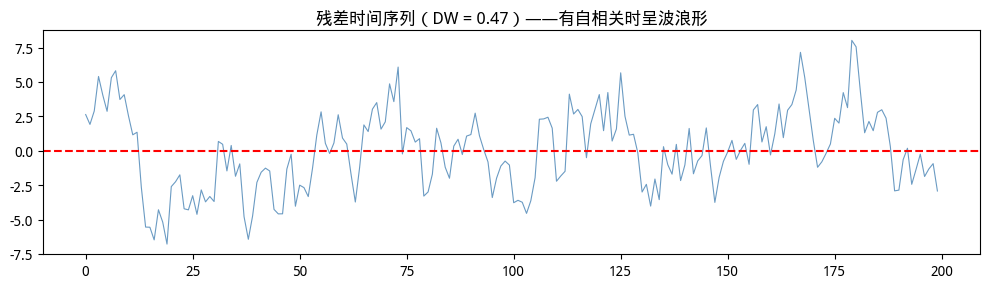

In [3]:
np.random.seed(42)
n = 200
t = np.arange(n)
# 含自相关的误差（AR(1)模型）
error = np.zeros(n)
error[0] = np.random.normal(0, 5)
for i in range(1, n):
    error[i] = 0.8 * error[i-1] + np.random.normal(0, 2)   # 高度自相关

x_ts = np.random.uniform(0, 10, n)
y_ts = 2 * x_ts + error

model_ts = sm.OLS(y_ts, sm.add_constant(x_ts)).fit()
dw = sm.stats.stattools.durbin_watson(model_ts.resid)

print(f"\nDurbin-Watson 统计量：{dw:.4f}")
print("解读：")
print("  ≈ 2：无自相关")
print("  < 1：正自相关（相邻残差方向相同）")
print("  > 3：负自相关（相邻残差方向相反）")

# 残差的时间序列图
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(model_ts.resid, color='steelblue', linewidth=0.8, alpha=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title(f'残差时间序列（DW = {dw:.2f}）——有自相关时呈波浪形', fontweight='bold')
plt.tight_layout()
plt.show()


**核心解读：**
- Durbin-Watson 检验得到的 DW= 0.4666， 说明残差存在极强正自相关；
- 残差图呈波浪形，说明残差连续正、连续负，来回波动。

**结论：**回归残差存在严重正自相关，OLS 回归不再有效。

这段代码告诉你：
如果数据是时间序列，残差很可能自相关，OLS 回归会失效，标准误、p 值都不可靠。

**处理方法**：
1. 加入滞后项（lagged features）
2. 使用 ARIMA 等时间序列模型

---

## 四、诊断清单

回归诊断项目不少，整理成一张清单方便自查：


In [ ]:
拟合后立即执行这 4 步：
✓ 1. 残差 vs 拟合值图 → 检查线性假设、异方差
✓ 2. Q-Q 图 → 检查残差正态性
✓ 3. VIF → 检查多重共线性（VIF > 10 警戒）
✓ 4. Durbin-Watson → 时间序列数据专用


---

## 五、📝 小结

| 问题 | 检测方法 | 影响 | 处理 |
|------|---------|------|------|
| 多重共线性 | VIF > 10 | 系数不稳定 | 删变量 / 正则化 |
| 异方差 | 残差扇形 / BP 检验 | 标准误失效 | 对数变换 / WLS |
| 自相关 | DW ≠ 2 | 系数和标准误失效 | 加滞后项 / ARIMA |

---

## 六、🏋️ 课后练习

1. 构造一个包含强共线性特征（r > 0.95）的数据集，计算 VIF，验证系数的不稳定性。
2. 对异方差数据做 `log(y)` 变换后重新建模，对比变换前后的残差图。
3. 下载一组时间序列数据（如股价），建立简单回归后计算 DW 统计量，判断是否存在自相关。

In [6]:
from sklearn.model_selection import train_test_split
print("练习1：多重共线性与VIF分析")

np.random.seed(42)
n = 200

# 构造高度相关的特征（强共线性）
x1 = np.random.uniform(0, 100, n)  # 原始特征1
x2 = x1 * 0.98 + np.random.normal(0, 2, n)  # 与x1高度相关（r ≈ 0.99）
x3 = np.random.uniform(0, 50, n)    # 独立特征
x4 = np.random.uniform(0, 30, n)    # 独立特征
y = 3 * x1 + 2 * x3 + 1 * x4 + np.random.normal(0, 5, n)

# 计算相关系数矩阵
print("\n相关系数矩阵：")
corr_matrix = np.corrcoef([x1, x2, x3, x4], rowvar=True)
features = ['x1', 'x2', 'x3', 'x4']
print("      ", "  ".join(f"{f:>6}" for f in features))
for i, row in enumerate(corr_matrix):
    print(f"{features[i]:<6}", "  ".join(f"{v:>6.3f}" for v in row))

print(f"\nx1与x2的相关系数: {corr_matrix[0,1]:.4f}")

# 计算VIF（方差膨胀因子）
def calculate_vif(X):
    """计算VIF"""
    vif_data = []
    for i in range(X.shape[1]):
        # 将当前列作为y，其他列作为X
        y_vif = X[:, i]
        X_vif = np.delete(X, i, axis=1)
        model = LinearRegression()
        model.fit(X_vif, y_vif)
        r2 = model.score(X_vif, y_vif)
        vif = 1 / (1 - r2) if r2 < 1 else float('inf')
        vif_data.append(vif)
    return np.array(vif_data)

X = np.column_stack([x1, x2, x3, x4])
vif = calculate_vif(X)

print("\nVIF（方差膨胀因子）分析：")
print("-" * 40)
for feat, v in zip(features, vif):
    status = "✓ 正常" if v < 5 else "⚠ 中度共线性" if v < 10 else "✗ 严重共线性"
    print(f"  {feat}: VIF = {v:.2f}  {status}")

print("\nVIF解释：")
print("  VIF < 5: 低共线性，系数稳定")
print("  5 ≤ VIF < 10: 中度共线性，需要关注")
print("  VIF ≥ 10: 严重共线性，系数不稳定")

# 演示系数的不稳定性
print("\n系数不稳定性演示：")
# 用原始数据训练
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model1 = LinearRegression()
model1.fit(X_train, y_train)

# 删除x2重新训练
X_no_x2 = np.column_stack([x1, x3, x4])
X_train_no2, X_test_no2, y_train2, y_test2 = train_test_split(X_no_x2, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X_train_no2, y_train2)

print(f"包含x2时 x1系数: {model1.coef_[0]:.4f}")
print(f"删除x2后 x1系数: {model2.coef_[0]:.4f}")
print(f"系数变化: {abs(model1.coef_[0] - model2.coef_[0]):.4f}")

练习1：多重共线性与VIF分析

相关系数矩阵：
           x1      x2      x3      x4
x1      1.000   0.998  -0.130  -0.030
x2      0.998   1.000  -0.127  -0.024
x3     -0.130  -0.127   1.000  -0.011
x4     -0.030  -0.024  -0.011   1.000

x1与x2的相关系数: 0.9978

VIF（方差膨胀因子）分析：
----------------------------------------
  x1: VIF = 225.12  ✗ 严重共线性
  x2: VIF = 224.85  ✗ 严重共线性
  x3: VIF = 1.02  ✓ 正常
  x4: VIF = 1.01  ✓ 正常

VIF解释：
  VIF < 5: 低共线性，系数稳定
  5 ≤ VIF < 10: 中度共线性，需要关注
  VIF ≥ 10: 严重共线性，系数不稳定

系数不稳定性演示：
包含x2时 x1系数: 2.9697
删除x2后 x1系数: 3.0241
系数变化: 0.0544


练习2：异方差与log变换

未变换前：
  R²: 0.9858
  残差均值: -0.0000
  残差标准差: 0.6330

log变换后：
  R²: 0.9620
  残差均值: -0.0000
  残差标准差: 0.0824


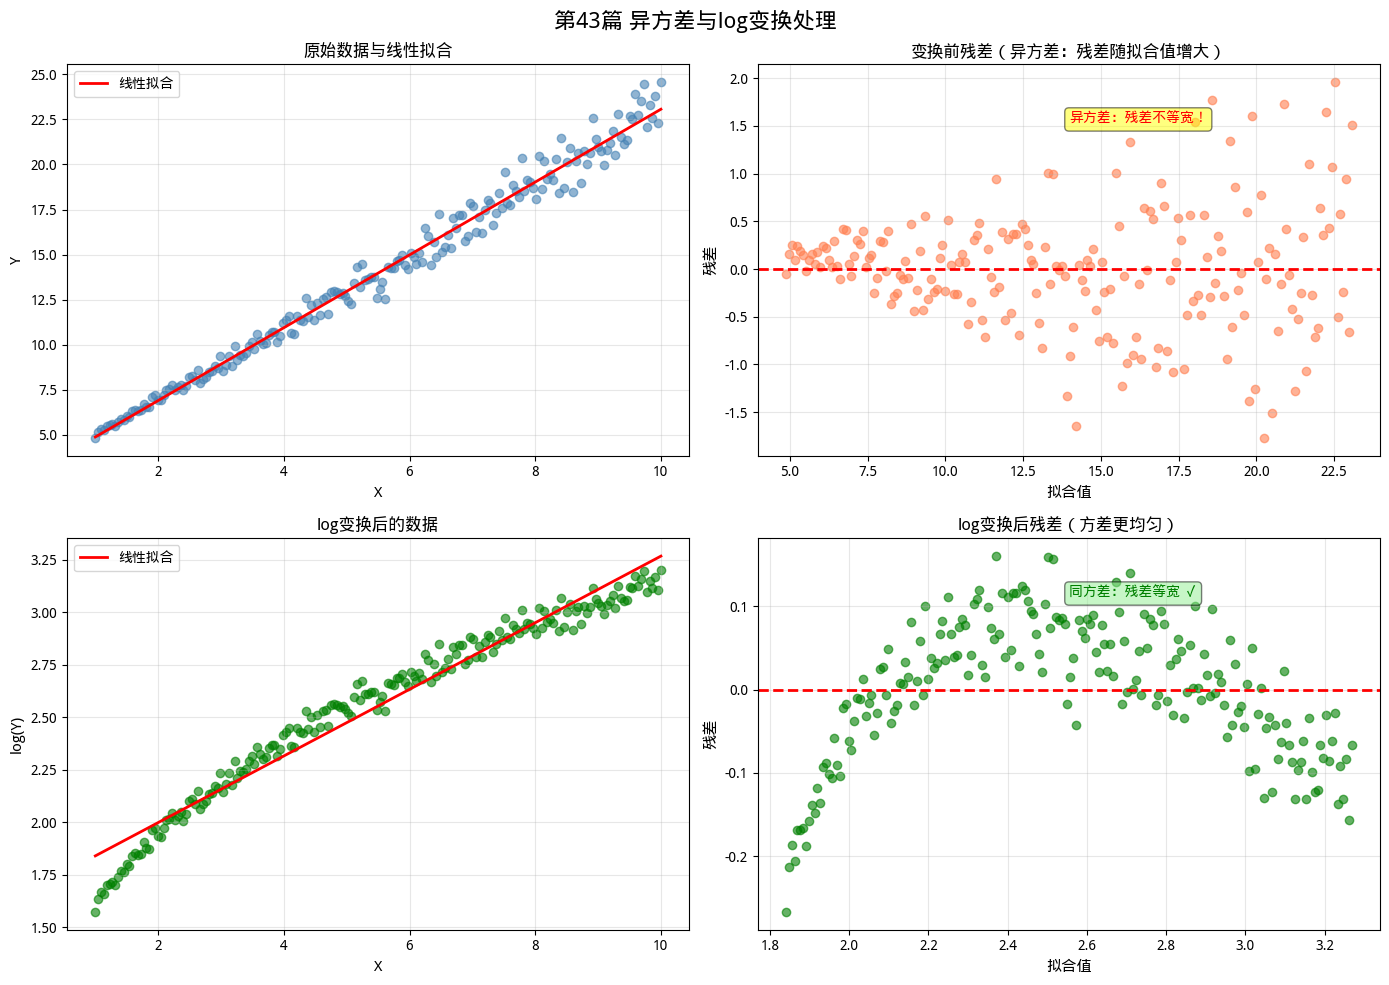


异方差处理方法总结：
1. log(y) 变换：适用于方差与均值成比例的情况
2. sqrt(y) 变换：适用于方差与均值成正比的情况
3. Box-Cox变换：更通用的变换方法
4. 加权最小二乘法（WLS）：给予不同样本不同权重


In [8]:
from sklearn.metrics import mean_squared_error, r2_score
print("练习2：异方差与log变换")

# 构造异方差数据（方差随预测值增加而增加）
np.random.seed(100)
n = 200
x_hetero = np.linspace(1, 10, n)
# 异方差：噪声标准差随x增加
noise_std = 0.1 * x_hetero  # 标准差与x成正比
y_hetero = 2 * x_hetero + 3 + np.random.normal(0, noise_std)

# 线性回归（未变换）
X_h = x_hetero.reshape(-1, 1)
model_hetero = LinearRegression()
model_hetero.fit(X_h, y_hetero)
y_pred_hetero = model_hetero.predict(X_h)
residuals_hetero = y_hetero - y_pred_hetero

print("\n未变换前：")
print(f"  R²: {r2_score(y_hetero, y_pred_hetero):.4f}")
print(f"  残差均值: {residuals_hetero.mean():.4f}")
print(f"  残差标准差: {residuals_hetero.std():.4f}")

# log变换
y_log = np.log(y_hetero)
model_log = LinearRegression()
model_log.fit(X_h, y_log)
y_pred_log = model_log.predict(X_h)
residuals_log = y_log - y_pred_log

print("\nlog变换后：")
print(f"  R²: {r2_score(y_log, y_pred_log):.4f}")
print(f"  残差均值: {residuals_log.mean():.4f}")
print(f"  残差标准差: {residuals_log.std():.4f}")

# 可视化对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('第43篇 异方差与log变换处理', fontsize=16, fontweight='bold')

# 图1：原始数据
ax1 = axes[0, 0]
ax1.scatter(x_hetero, y_hetero, alpha=0.6, color='steelblue')
ax1.plot(x_hetero, y_pred_hetero, color='red', linewidth=2, label='线性拟合')
ax1.set_xlabel('X', fontsize=11)
ax1.set_ylabel('Y', fontsize=11)
ax1.set_title('原始数据与线性拟合', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2：变换前残差（明显漏斗形/喇叭形）
ax2 = axes[0, 1]
ax2.scatter(y_pred_hetero, residuals_hetero, alpha=0.6, color='coral')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('拟合值', fontsize=11)
ax2.set_ylabel('残差', fontsize=11)
ax2.set_title('变换前残差（异方差：残差随拟合值增大）', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.text(0.5, 0.85, '异方差：残差不等宽！',
         transform=ax2.transAxes, fontsize=10, color='red',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# 图3：log变换后数据
ax3 = axes[1, 0]
ax3.scatter(x_hetero, y_log, alpha=0.6, color='green')
ax3.plot(x_hetero, y_pred_log, color='red', linewidth=2, label='线性拟合')
ax3.set_xlabel('X', fontsize=11)
ax3.set_ylabel('log(Y)', fontsize=11)
ax3.set_title('log变换后的数据', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 图4：变换后残差
ax4 = axes[1, 1]
ax4.scatter(y_pred_log, residuals_log, alpha=0.6, color='green')
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('拟合值', fontsize=11)
ax4.set_ylabel('残差', fontsize=11)
ax4.set_title('log变换后残差（方差更均匀）', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.text(0.5, 0.85, '同方差：残差等宽 ✓',
         transform=ax4.transAxes, fontsize=10, color='green',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n异方差处理方法总结：")
print("1. log(y) 变换：适用于方差与均值成比例的情况")
print("2. sqrt(y) 变换：适用于方差与均值成正比的情况")
print("3. Box-Cox变换：更通用的变换方法")
print("4. 加权最小二乘法（WLS）：给予不同样本不同权重")

练习3：DW统计量与自相关检验

股价时间序列回归分析：
  样本量: 100
  时间范围: 0 - 99
  股价范围: 100.00 - 113.37

Durbin-Watson统计量: 0.2353

DW统计量解读：
----------------------------------------
  DW ≈ 2: 无自相关（残差独立）
  DW < 2: 正自相关（相邻残差倾向同号）
  DW > 2: 负自相关（相邻残差倾向异号）
  DW < 1: 强烈正自相关
  DW > 3: 强烈负自相关

DW = 0.2353 < 1.5: 存在强正自相关 ✗

残差一阶自相关系数: 0.8799
理论DW ≈ 2(1-r) = 0.2401


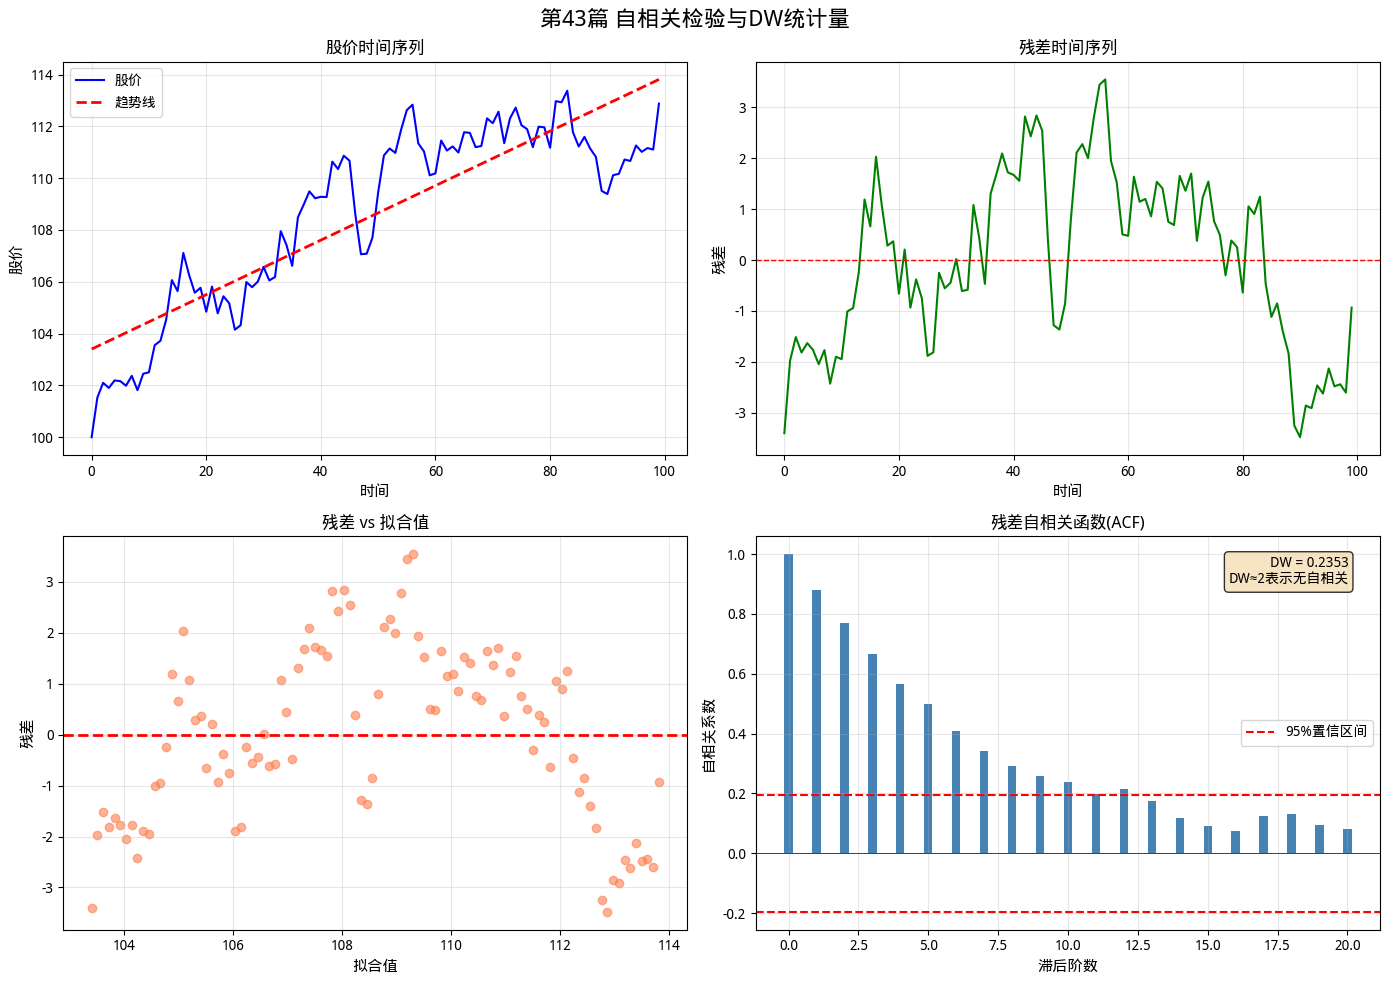

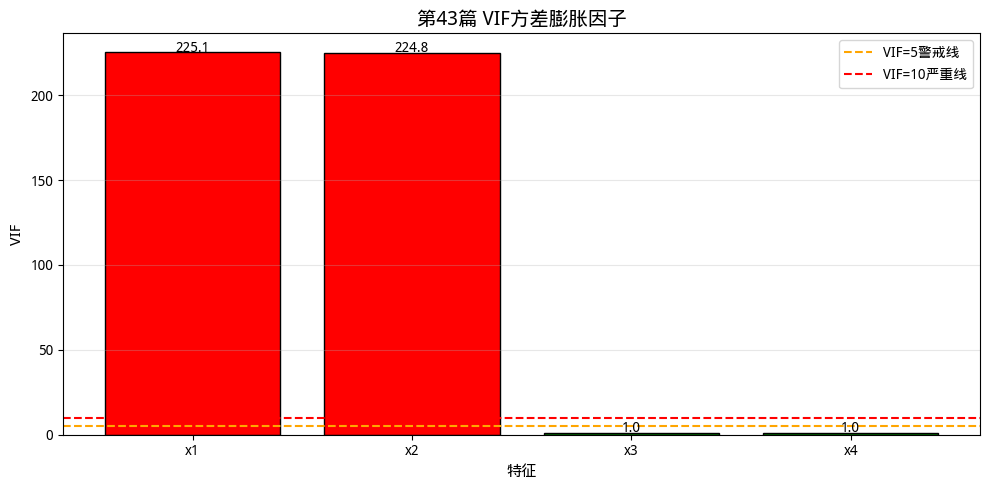


总结
1. VIF > 10时存在严重多重共线性，需要删除或合并特征
2. 异方差可用log/sqrt变换或加权最小二乘法处理
3. DW统计量≈2表示无自相关，偏离2表示存在自相关
4. 自相关问题常用广义最小二乘法(GLS)或Newey-West标准误


In [10]:
print("练习3：DW统计量与自相关检验")

def durbin_watson(residuals):
    """
    计算Durbin-Watson统计量
    DW ≈ 2(1-r) 其中r是残差的一阶自相关系数
    DW接近2表示无自相关
    """
    diff = np.diff(residuals)  # 残差的一阶差分
    numerator = np.sum(diff**2)
    denominator = np.sum(residuals**2)
    return numerator / denominator if denominator != 0 else 0

# 构造时间序列数据（股价）
np.random.seed(200)
n_time = 100
time = np.arange(n_time)
# 股价：有一定自相关（今天的股价与昨天相关）
price = 100 + 0.8 * np.cumsum(np.random.randn(n_time))
price = price - price[0] + 100  # 调整到从100开始

# 简单回归：price = β0 + β1*time + ε
X_time = time.reshape(-1, 1)
model_time = LinearRegression()
model_time.fit(X_time, price)
price_pred = model_time.predict(X_time)
residuals_time = price - price_pred

# 计算DW统计量
dw_stat = durbin_watson(residuals_time)

print("\n股价时间序列回归分析：")
print(f"  样本量: {n_time}")
print(f"  时间范围: {time[0]} - {time[-1]}")
print(f"  股价范围: {price.min():.2f} - {price.max():.2f}")
print(f"\nDurbin-Watson统计量: {dw_stat:.4f}")

# 解释DW统计量
print("\nDW统计量解读：")
print("-" * 40)
print("  DW ≈ 2: 无自相关（残差独立）")
print("  DW < 2: 正自相关（相邻残差倾向同号）")
print("  DW > 2: 负自相关（相邻残差倾向异号）")
print("  DW < 1: 强烈正自相关")
print("  DW > 3: 强烈负自相关")

if dw_stat < 1.5:
    print(f"\nDW = {dw_stat:.4f} < 1.5: 存在强正自相关 ✗")
elif dw_stat > 2.5:
    print(f"\nDW = {dw_stat:.4f} > 2.5: 存在负自相关 ✗")
else:
    print(f"\nDW = {dw_stat:.4f} 接近2: 无明显自相关 ✓")

# 计算残差的自相关系数
autocorr_lag1 = np.corrcoef(residuals_time[:-1], residuals_time[1:])[0, 1]
print(f"\n残差一阶自相关系数: {autocorr_lag1:.4f}")
print(f"理论DW ≈ 2(1-r) = {2*(1-autocorr_lag1):.4f}")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('第43篇 自相关检验与DW统计量', fontsize=16, fontweight='bold')

# 图1：时间序列
ax1 = axes[0, 0]
ax1.plot(time, price, 'b-', linewidth=1.5, label='股价')
ax1.plot(time, price_pred, 'r--', linewidth=2, label='趋势线')
ax1.set_xlabel('时间', fontsize=11)
ax1.set_ylabel('股价', fontsize=11)
ax1.set_title('股价时间序列', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2：残差时间序列
ax2 = axes[0, 1]
ax2.plot(time, residuals_time, 'g-', linewidth=1.5)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('时间', fontsize=11)
ax2.set_ylabel('残差', fontsize=11)
ax2.set_title('残差时间序列', fontsize=12)
ax2.grid(True, alpha=0.3)

# 图3：残差 vs 拟合值
ax3 = axes[1, 0]
ax3.scatter(price_pred, residuals_time, alpha=0.6, color='coral')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('拟合值', fontsize=11)
ax3.set_ylabel('残差', fontsize=11)
ax3.set_title('残差 vs 拟合值', fontsize=12)
ax3.grid(True, alpha=0.3)

# 图4：残差自相关图（ACF）
ax4 = axes[1, 1]
from scipy import stats
max_lag = 20
acf_values = [1.0]
for lag in range(1, max_lag + 1):
    corr = np.corrcoef(residuals_time[:-lag], residuals_time[lag:])[0, 1]
    acf_values.append(corr)

lags = np.arange(0, max_lag + 1)
ax4.bar(lags, acf_values, width=0.3, color='steelblue')
ax4.axhline(y=0, color='black', linewidth=0.5)
# 95%置信区间
conf_int = 1.96 / np.sqrt(n_time)
ax4.axhline(y=conf_int, color='red', linestyle='--', label=f'95%置信区间')
ax4.axhline(y=-conf_int, color='red', linestyle='--')
ax4.set_xlabel('滞后阶数', fontsize=11)
ax4.set_ylabel('自相关系数', fontsize=11)
ax4.set_title('残差自相关函数(ACF)', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

# 添加DW统计量注释
ax4.text(0.95, 0.95, f'DW = {dw_stat:.4f}\nDW≈2表示无自相关',
         transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# VIF可视化
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vif]
bars = ax.bar(features, vif, color=colors, edgecolor='black')
ax.axhline(y=5, color='orange', linestyle='--', label='VIF=5警戒线')
ax.axhline(y=10, color='red', linestyle='--', label='VIF=10严重线')
ax.set_xlabel('特征', fontsize=11)
ax.set_ylabel('VIF', fontsize=11)
ax.set_title('第43篇 VIF方差膨胀因子', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, v in zip(bars, vif):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r'c:\Users\Mushaoyong\WorkBuddy\20260401154618\第43篇_练习1_VIF柱状图.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("总结")
print("=" * 60)
print("1. VIF > 10时存在严重多重共线性，需要删除或合并特征")
print("2. 异方差可用log/sqrt变换或加权最小二乘法处理")
print("3. DW统计量≈2表示无自相关，偏离2表示存在自相关")
print("4. 自相关问题常用广义最小二乘法(GLS)或Newey-West标准误")

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 44 篇：正则化 — Ridge 与 Lasso 防止过拟合**
>
> 下篇学正则化——特征太多时怎么选，如何让模型更稳健，Ridge 和 Lasso 各有什么优势。

---

*跟着小荷，数据分析路上不迷路～*